# Sequential uncertainty reduction: Loop 1 to Loop 2 (MgkPro)

Reads the AnnData objects, derives cell-type proportions per experiment, predicts Loop 0/1 with the forward model, and plots the resulting uncertainty deltas for the MgkPro population.

In [1]:
import pandas as pd
from tqdm import tqdm 
import scanpy as sc
import seaborn as sns
import sys
import os 
import logging 
from omegaconf import OmegaConf, DictConfig
from hydra import initialize, compose
from scipy.spatial.distance import cdist
from sklearn.preprocessing import LabelEncoder
import torch
import numpy as np
from pathlib import Path 
import torch.nn.functional as F
import matplotlib.pyplot as plt

from labcompass.constants import DataFields
sys.path.insert(0, "../../shared_utils/")
from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn
)

logger = logging.getLogger(__name__)

In [2]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]',
                 'sr1_[nm]', 
                 'um171_[nm]',
                 'um729_[µm]', 
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]', 
                 'ldl_[ng_ml]', 
                 'il3_[ng_ml]', 
                 'o2_[%]',
                 'days_of_culture', 
                'experiment_number']

## Read the AnnDatas

In [3]:
obs_l1 = sc.read_h5ad("../../project_folder/output/loops/data/loop1/adata_500k.h5ad").obs.dropna()
obs_l2 = sc.read_h5ad("../../project_folder/derived/annotated/loop2_annotated.h5ad").obs.dropna()
obs_l2p5 = sc.read_h5ad("../../project_folder/derived/annotated/loop2p5_annotated.h5ad").obs.dropna()
obs_l2 = pd.concat([obs_l2, obs_l2p5], axis=0)

obs_l1.cell_type = obs_l1.cell_type.astype(str)
obs_l2.cell_type = obs_l2.cell_type.astype(str)

to_keep = ["239", "240","248"]

to_keep = [str(i) for i in to_keep]

obs_l2 = obs_l2.loc[obs_l2.experiment_number.isin(to_keep)]

## Derive cell type proportions per experiment

In [4]:
all_cell_types = np.unique(obs_l1.cell_type.astype(str))

real_ct_proportions_l1 = []
real_ct_proportions_l2 = []

for exp in list(np.unique(obs_l1.experiment_number)):
    cell_type_exp = obs_l1[obs_l1.experiment_number==exp]
    cell_type_exp = cell_type_exp.cell_type.value_counts() / len(cell_type_exp)
    for cell_type in all_cell_types: 
        if cell_type not in cell_type_exp.index:
            cell_type_exp[cell_type] = 0
    cell_type_exp = cell_type_exp[all_cell_types]
    real_ct_proportions_l1.append(cell_type_exp.values)

for exp in list(np.unique(obs_l2.experiment_number)):
    cell_type_exp = obs_l2[obs_l2.experiment_number==exp]
    cell_type_exp = cell_type_exp.cell_type.value_counts() / len(cell_type_exp)    
    for cell_type in all_cell_types: 
        if cell_type not in cell_type_exp.index:
            cell_type_exp[cell_type] = 0
    cell_type_exp = cell_type_exp[all_cell_types]
    real_ct_proportions_l2.append(cell_type_exp.values)

In [5]:
real_ct_proportions_l1 = pd.DataFrame(np.stack(real_ct_proportions_l1))
real_ct_proportions_l2 = pd.DataFrame(np.stack(real_ct_proportions_l2))

In [6]:
real_ct_proportions_l1.columns = all_cell_types
real_ct_proportions_l2.columns = all_cell_types

In [7]:
real_ct_proportions = pd.concat([real_ct_proportions_l1, real_ct_proportions_l2])

In [8]:
real_ct_proportions = real_ct_proportions.reset_index(drop=True)

In [9]:
real_ct_proportions

,CD14Mono,CD16Mono,CyclingPro1,CyclingPro2,Early_GMP,EosBasMast1,EosBasMast2,EosBasMast3,EryPro,GMP-Neutro,...,MPP,MPP_MgkEry,MgKEryPro1,MgKEryPro2,ProB,earlyMPP,late_MgkPro,preProB,pre_cDC1,pre_cDC2
0,0.000253,0.000000,0.000253,0.000253,0.120253,0.054937,0.002785,0.005316,0.000000,0.220000,...,0.394177,0.076709,0.058734,0.007595,0.000506,0.002278,0.002785,0.002785,0.000000,0.000759
1,0.000000,0.000000,0.000000,0.000495,0.122525,0.092574,0.006683,0.000000,0.023515,0.147277,...,0.006931,0.000000,0.164109,0.380446,0.000000,0.000990,0.022030,0.002723,0.004950,0.000000
2,0.000250,0.000000,0.000000,0.001998,0.080669,0.083666,0.010240,0.000749,0.017483,0.140859,...,0.005744,0.000250,0.250500,0.366883,0.000250,0.000500,0.014486,0.001499,0.005744,0.000000
3,0.000000,0.000000,0.000251,0.001002,0.093687,0.111974,0.014529,0.000251,0.071643,0.130261,...,0.018036,0.000000,0.209920,0.284068,0.000251,0.001503,0.013527,0.001253,0.003257,0.000000
4,0.001225,0.000000,0.000000,0.000245,0.038226,0.030140,0.004411,0.000245,0.001960,0.174712,...,0.000245,0.000245,0.271257,0.450625,0.000000,0.002695,0.011517,0.002940,0.006616,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,0.000746,0.021150,0.000000,0.000000,0.012690,0.000000,0.063697,0.003483,0.000498,0.665340,...,0.006967,0.037074,0.109978,0.001493,0.000000,0.001742,0.000000,0.000746,0.000000,0.000746
121,0.005551,0.009589,0.000252,0.000000,0.038355,0.000000,0.105728,0.007065,0.000505,0.377239,...,0.016149,0.081756,0.213727,0.001514,0.000252,0.003533,0.000000,0.000757,0.000757,0.000757
122,0.001350,0.016884,0.000054,0.000018,0.059221,0.087139,0.001332,0.000324,0.058177,0.082243,...,0.060967,0.000000,0.100549,0.000000,0.000000,0.003636,0.408928,0.000180,0.075745,0.000324
123,0.000270,0.067231,0.316479,0.001134,0.000018,0.000018,0.060859,0.000450,0.000198,0.128827,...,0.005652,0.000036,0.210818,0.000000,0.000090,0.002358,0.096337,0.000180,0.022068,0.000486


Get cell type proportions

In [10]:
obs_l1 = obs_l1.loc[:, protocol_cols].drop_duplicates().sort_values(by="experiment_number")
obs_l2 = obs_l2.loc[:, protocol_cols].drop_duplicates().sort_values(by="experiment_number")
obs = pd.concat([obs_l1, obs_l2]).drop(labels=["experiment_number"], axis=1)

In [11]:
adata_l1 = sc.AnnData(X=obs)
adata_l1.obs = {"Loop": ["Loop1" for _ in range(len(obs_l1))] + ["Loop2" for _ in range(len(obs_l2))]}
adata_l1.uns["real_proportions"] = real_ct_proportions

/home/icb/alessandro.palma/.local/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: X converted to numpy array with dtype object
  return fn(*args_all, **kw)


In [12]:
sc.pp.log1p(adata_l1)
sc.tl.pca(adata_l1)
sc.pp.neighbors(adata_l1)
sc.tl.umap(adata_l1)

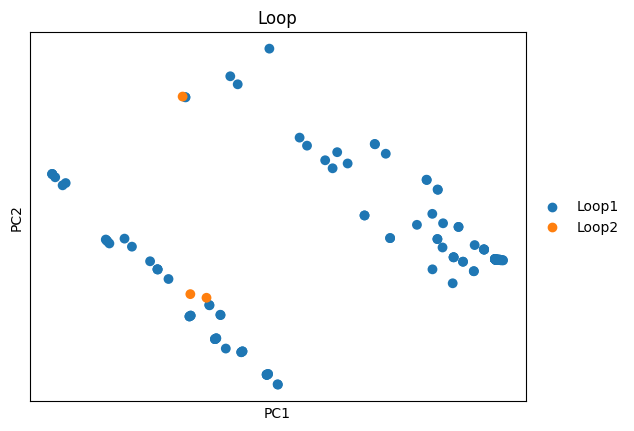

In [13]:
sc.pl.pca(adata_l1, s=200, color="Loop")

## Compute the decrease of uncertainty of forward model for subsequent opt

In [14]:
def uncertainty_quantification(
    forward_model,
    base_cfg,
    X_candidates, 
    y_prop_true, 
    target_cell_types, 
    n_noise_samples,
    n_populations, 
    cell_type_column):
    
    protocol_columns = base_cfg["annotation"]["protocol_columns"]
    y_prop_true = torch.from_numpy(y_prop_true[:, None, :]).to("cuda")

    ct_le = LabelEncoder()
    ct_values = target_prediction_model.train_data.adata.obs[cell_type_column].values
    ct_le.fit(ct_values)
    classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

    # Take cell type index 
    cell_type_index = classes.index(target_cell_types)
    ct_safe_string = target_cell_types.replace("/", ":") # cell type dir

    X_candidates = torch.from_numpy(X_candidates).float().to("cuda")
    X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
    condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
    batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}

    forward_out = forward_model.predict(
        batch_dict,
        no_grad=True,
        fix_noise=False,
        num_time_steps=100
    )
    
    y_pred = forward_out["target_prediction_data"][cell_type_column].view(X_candidates_add.shape[0],
                                                                     n_populations,
                                                                     -1,
                                                                     len(classes))  
    y_pred_softmax = F.softmax(y_pred, dim=-1)

    # Take the mean proportions 
    y_pred_mean = y_pred.mean(2)  # no_candidates x no_populations x no_cell_types 

    y_pred_softmax = y_pred_softmax.mean(2)  # no_candidates x no_populations x no_cell_types 

    # Collect cell type of interest 
    y_pred_ct_std = y_pred_softmax[..., cell_type_index].std(1).detach().cpu().numpy()  # standard deviation prob cell type of interest 
    # Calculate loss
    y_target_ct = np.zeros((1, len(classes)))
    y_target_ct[:, cell_type_index] = 1.0
    y_target_ct = torch.from_numpy(y_target_ct)
    y_target_ct = y_target_ct.unsqueeze(0).to("cuda")  # 1 x 1 x no_cell_types
    
    logger.info("Compute loss function")
    loss_fn = lambda pred, target: -torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)
    with torch.no_grad():
        loss = loss_fn(y_pred_mean, y_target_ct)
        loss_all_ct = loss_fn(y_pred_mean, y_prop_true)

    loss_std = loss.std(1).detach().cpu().numpy()  # no_candidates
    loss_mean = loss.mean(1).detach().cpu().numpy()  # no_candidates
    loss_mean_all_ct = loss_all_ct.mean(1).detach().cpu().numpy()  # no_candidates
    return loss_mean_all_ct, loss_mean, loss_std

In [15]:
base_config_path = "../../inverse/loss_guidance/config/"
base_config_name = "run_inverse"
target_cell_types = "late_MgkPro"
n_noise_samples = 2000
n_populations = 10
cell_type_column = "cell_type" 

# Initialize paths 
os.environ["REPO_ROOT"] = os.path.abspath("../..")

with initialize(config_path=base_config_path, version_base=None):
    cfg_l1 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop1", 
                   f"loss=default",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

with initialize(config_path=base_config_path, version_base=None):
    cfg_l2 = compose(
        config_name=base_config_name,
        overrides=[f"paths=loop2p5_replicate", 
                   f"loss=loop2p5_replicate",
                   f"annotation=bloodplus", 
                   f"constraints=default_all_cols"])

## Predict loop0 

In [16]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l1, logger=logger)

In [17]:
unc_l1_pred = []
loss_l1_pred = []

for _ in tqdm(range(5)):
    loss_all_ct, loss, unc = uncertainty_quantification(
        forward_model, 
        cfg_l1,
        adata_l1.X, 
        adata_l1.uns["real_proportions"].values,
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        cell_type_column)
    
    unc_l1_pred.append(unc)
    loss_l1_pred.append(loss_all_ct)

100%|██████████| 5/5 [01:56<00:00, 23.21s/it]


In [18]:
unc_l1_pred = np.stack(unc_l1_pred, axis=0).mean(0)

In [19]:
loss_l1_pred = np.stack(loss_l1_pred, axis=0).mean(0)

In [20]:
del forward_model
del target_prediction_model

## Predict loop1

In [21]:
forward_model, (_, target_prediction_model) = get_forward_model(cfg_l2, logger=logger)

In [22]:
unc_l2_pred = []
loss_l2_pred = []                                                                                                                                      = []

for _ in tqdm(range(5)):
    loss_all_ct, loss, unc = uncertainty_quantification(
        forward_model, 
        cfg_l2,
        adata_l1.X,
        adata_l1.uns["real_proportions"].values,
        target_cell_types, 
        n_noise_samples,
        n_populations, 
        "cell_type_reannot_final")
    
    unc_l2_pred.append(unc)
    loss_l2_pred.append(loss_all_ct)

100%|██████████| 5/5 [01:56<00:00, 23.25s/it]


In [23]:
unc_l2_pred = np.stack(unc_l2_pred, axis=0).mean(0)

In [24]:
loss_l2_pred = np.stack(loss_l2_pred, axis=0).mean(0)

In [25]:
del forward_model
del target_prediction_model

# Plot both uncertanties and also new recipes

In [26]:
unc_delta = unc_l1_pred - unc_l2_pred
loss_delta = loss_l1_pred - loss_l2_pred

## Deltas

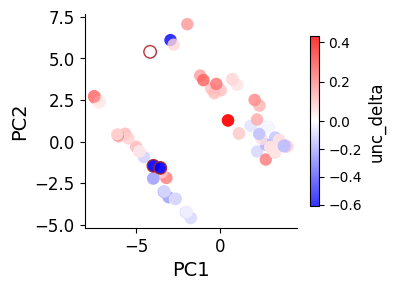

In [27]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(4, 3))
# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
mask_loop2 = adata_l1.obs["Loop"] == "Loop2"
pca_coords = adata_l1.obsm["X_pca"]

# Center the colormap at 0
vals = unc_delta[mask_loop1]
vals_l2 = unc_delta[mask_loop2]

norm = mcolors.TwoSlopeNorm(vmin=vals.min(), vcenter=0, vmax=vals.max())

# Loop1: colored by unc_delta (continuous colormap, centered at 0)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=vals,
    cmap="bwr",
    norm=norm,
    s=80,
    alpha=0.8,
    edgecolor="none",
    marker="o",
    label="Loop0",
)

# Loop2: solid red, different marker, on top
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=vals_l2, 
    cmap="bwr",
    norm=norm, 
    s=80,
    alpha=0.9,
    edgecolor="firebrick",
    marker="o",
    label="Loop1",
    zorder=3,
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc_delta", fontsize=12)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)
plt.tight_layout()
plt.show()

In [28]:
# fig, ax = plt.subplots(figsize=(4, 3))
# # Split by Loop
# mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
# mask_loop2 = adata_l1.obs["Loop"] == "Loop2"
# pca_coords = adata_l1.obsm["X_pca"]

# # Center the colormap at 0
# vals = loss_delta[mask_loop1]
# norm = mcolors.TwoSlopeNorm(vmin=vals.min(), vcenter=0, vmax=vals.max())

# # Loop1: colored by unc_delta (continuous colormap, centered at 0)
# sc_plot = ax.scatter(
#     pca_coords[mask_loop1, 0],
#     pca_coords[mask_loop1, 1],
#     c=vals,
#     cmap="bwr",
#     norm=norm,
#     s=80,
#     alpha=0.8,
#     edgecolor="none",
#     marker="o",
#     label="Loop0",
# )

# # Loop2: solid red, different marker, on top
# ax.scatter(
#     pca_coords[mask_loop2, 0],
#     pca_coords[mask_loop2, 1],
#     color="firebrick",
#     s=100,
#     alpha=0.9,
#     edgecolor="firebrick",
#     marker="^",
#     label="Loop1",
#     zorder=3,
# )

# # Colorbar for the uncertainty values
# cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
# cbar.set_label("unc_delta", fontsize=12)
# ax.set_xlabel("PC1", fontsize=14)
# ax.set_ylabel("PC2", fontsize=14)
# ax.tick_params(axis="both", labelsize=12)
# ax.spines[["top", "right"]].set_visible(False)
# # ax.legend(fontsize=11, loc="best", frameon=True)
# plt.tight_layout()
# plt.show()

## Deltas

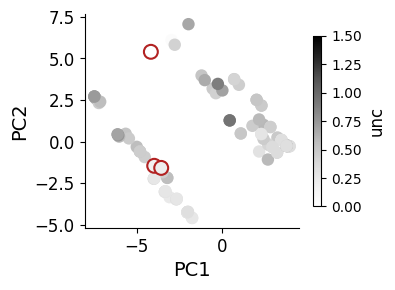

In [29]:
fig, ax = plt.subplots(figsize=(4, 3))
# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
mask_loop2 = adata_l1.obs["Loop"] == "Loop2"
pca_coords = adata_l1.obsm["X_pca"]

# Loop1: colored by unc_l1_pred (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=unc_l1_pred[mask_loop1],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
    label="Loop1",
)

# Loop2: colored the same way, but circled in firebrick
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=unc_l1_pred[mask_loop2],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=100,
    edgecolor="firebrick",
    linewidth=1.5,
    marker="o",
    label="Loop2",
    zorder=3,
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)
plt.tight_layout()
plt.savefig("plots/pca_trans_1_to_2_plot_2_mgkpro.png", dpi=700, bbox_inches="tight")
plt.show()

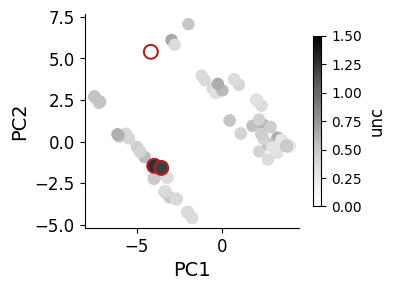

In [30]:
fig, ax = plt.subplots(figsize=(4, 3))
# Split by Loop
mask_loop1 = adata_l1.obs["Loop"] == "Loop1"
mask_loop2 = adata_l1.obs["Loop"] == "Loop2"
pca_coords = adata_l1.obsm["X_pca"]

# Loop1: colored by unc_l2_pred (continuous colormap)
sc_plot = ax.scatter(
    pca_coords[mask_loop1, 0],
    pca_coords[mask_loop1, 1],
    c=unc_l2_pred[mask_loop1],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=80,
    edgecolor="none",
    marker="o",
    label="Loop1",
)

# Loop2: colored the same way, but circled in firebrick
ax.scatter(
    pca_coords[mask_loop2, 0],
    pca_coords[mask_loop2, 1],
    c=unc_l2_pred[mask_loop2],
    cmap="Greys",
    vmin=0,
    vmax=1.5,
    s=100,
    edgecolor="firebrick",
    linewidth=1.5,
    marker="o",
    label="Loop2",
    zorder=3,
)

# Colorbar for the uncertainty values
cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.8)
cbar.set_label("unc", fontsize=12)
ax.set_xlabel("PC1", fontsize=14)
ax.set_ylabel("PC2", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(fontsize=11, loc="best", frameon=True)
plt.tight_layout()
plt.savefig("plots/pca_trans_1_to_2_plot_3_mgkpro.png", dpi=700, bbox_inches="tight")
plt.show()

## Compare losses 

In [31]:
predict_losses = {"Loop": ["Loop1" for _ in range(3)] + ["Loop2" for _ in range(3)],
                 "Loss": np.concatenate([loss_l1_pred[mask_loop2], loss_l2_pred[mask_loop2]]),
                 "protocol": ["239", "240", "248"]*2}

predict_losses = pd.DataFrame(predict_losses)

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(
    predict_losses, 
    x="protocol", 
    y="Loss", 
    hue="Loop",
    palette={"Loop1": "#2a9d8f", "Loop2": "#e76f51"}
)
plt.savefig("plots/comp_performance_new_exp_loop1_loop2.svg")